In [1]:
from econml.dml import CausalForestDML
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier

c:\Users\Roma\.virtualenvs\causal-promo-opt-N4J8iauW\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load data and engineer variable

In [3]:
df = pd.read_csv('../data/software_usage_promotion.csv')

df['Combined Treatment'] = (df['Discount'] *
                            df['Tech Support']).astype('category')
confounders = [
    'Size', 'Employee Count', 'PC Count', 'IT Spend', 'Major Flag',
    'Global Flag', 'Commercial Flag', 'SMC Flag'
]

### Model with CausalForest

In [4]:
def make_cf():
    return CausalForestDML(
        model_y=GradientBoostingRegressor(),
        model_t=DecisionTreeClassifier(max_depth=3),
        discrete_treatment=True,
        n_estimators=100,
        max_depth=10,
        random_state=42
    )

In [5]:
cf_discount = make_cf().fit(Y=df['Revenue'],
       T=df['Discount'],
       X=df[confounders])

cf_tech = make_cf().fit(Y=df['Revenue'], T=df['Tech Support'], X=df[confounders])

cf_combined = make_cf().fit(Y=df['Revenue'], T=df['Combined Treatment'], X=df[confounders])

In [6]:
df['cate_discount'] = cf_discount.effect(df[confounders])
df['cate_tech_support'] = cf_tech.effect(df[confounders])
df['cate_both'] = cf_combined.effect(df[confounders])


In [7]:
df

,Global Flag,Major Flag,SMC Flag,Commercial Flag,IT Spend,Employee Count,PC Count,Size,Tech Support,Discount,Revenue,Combined Treatment,cate_discount,cate_tech_support,cate_both
0,1,0,1,0,45537,26,26,152205,0,1,17688.363000,0,7232.812097,7376.361386,9482.935306
1,0,0,1,1,20842,107,70,159038,0,1,14981.435590,0,7528.192742,7943.415407,10218.213722
2,0,0,0,1,82171,10,7,264935,1,1,32917.138940,1,12790.422060,10024.914327,12666.878773
3,0,0,0,0,30288,40,39,77522,1,1,14773.768550,1,5832.046579,7666.602287,8172.647822
4,0,0,1,0,25930,37,43,91446,1,1,17098.698230,1,5104.419849,7182.090543,8166.909251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0,0,1,1,46186,74,48,141579,0,1,13930.128620,0,7817.394655,7590.780968,9766.037567
1996,0,0,1,0,39683,12,13,111848,0,0,4753.072214,0,5119.256264,6967.313173,8750.309625
1997,0,1,0,0,4195,14,17,11924,0,0,2161.745939,0,872.157783,5271.041208,5009.250146
1998,1,0,0,1,10664,68,47,40037,1,1,17694.820790,1,2187.679174,5764.705948,5691.808220


In [7]:
df.describe()

,Global Flag,Major Flag,SMC Flag,Commercial Flag,IT Spend,Employee Count,PC Count,Size,Tech Support,Discount,Revenue,cate_discount,cate_tech_support,cate_both
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.202000,0.1950,0.504500,0.691000,28272.703000,61.115000,57.345500,113159.120000,0.503000,0.510500,15397.917422,5428.977596,6763.736641,7904.375417
std,0.401593,0.3963,0.500105,0.462197,28207.138885,53.449707,52.861123,100987.600092,0.500116,0.500015,11290.944451,4667.963423,1230.127382,2881.190418
min,0.000000,0.0000,0.000000,0.000000,1161.000000,10.000000,6.000000,10101.000000,0.000000,0.000000,-616.572451,-417.447996,4824.333311,3625.221744
25%,0.000000,0.0000,0.000000,0.000000,8914.000000,24.000000,22.000000,39282.000000,0.000000,0.000000,7545.052008,1564.648468,5681.317392,5314.076764
50%,0.000000,0.0000,1.000000,1.000000,19210.500000,44.000000,41.000000,81378.000000,1.000000,1.000000,12582.446440,4598.362823,6590.994953,7774.510748
75%,0.000000,0.0000,1.000000,1.000000,37991.500000,79.000000,74.000000,155635.000000,1.000000,1.000000,19662.979475,7934.131327,7601.065817,9784.256960
max,1.000000,1.0000,1.000000,1.000000,259808.000000,535.000000,407.000000,766485.000000,1.000000,1.000000,86006.924450,21028.794217,11213.627435,18088.299393


In [8]:
def row_optimal_strategy(row):
    discount = row['Discount']
    tech = row['Tech Support']

    match (discount, tech):
        case (0, 0):  # None
            lifts = {
                'none': 0,
                'discount': row['cate_discount'],
                'tech_support': row['cate_tech_support'],
                'both': row['cate_both']
            }
        case (1, 0): # Discount
            lifts = {
                'none': -row['cate_discount'],
                'discount': 0,
                'tech_support': row['cate_tech_support'] - row['cate_discount'],
                'both': row['cate_both'] - row['cate_discount']
            }
        case (0, 1): # Tech
            lifts = {
                'none': -row['cate_tech_support'],
                'discount': row['cate_discount'] - row['cate_tech_support'],
                'tech_support': 0,
                'both': row['cate_both'] - row['cate_tech_support']
            }
        case (1, 1): # Both
            lifts = {
                'none': -row['cate_both'],
                'discount': row['cate_discount'] - row['cate_both'],
                'tech_support': row['cate_tech_support'] - row['cate_both'],
                'both': 0
            }

        case _:  # fallback
            raise ValueError("Unexpected treatment combination")

    best_action = max(lifts, key=lifts.get)
    best_lift = lifts[best_action]

    return pd.Series({'recommended_action': best_action, 'incremental_lift': best_lift})


In [9]:
df[['recommended_action', 'incremental_lift']] = df.apply(row_optimal_strategy, axis=1)

In [10]:
rec_no_treatment = df[df.incremental_lift==0]

In [11]:
rec_no_treatment.shape

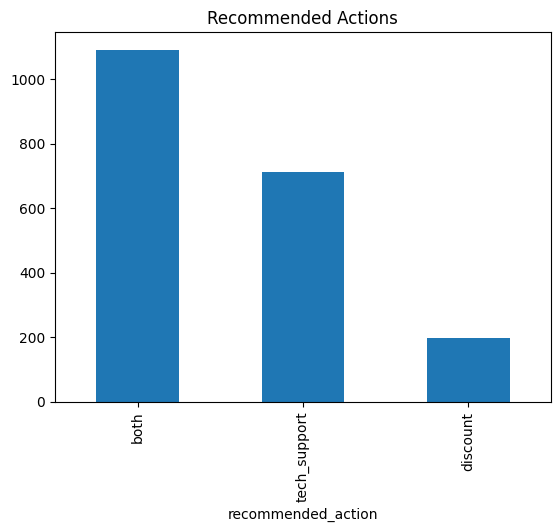

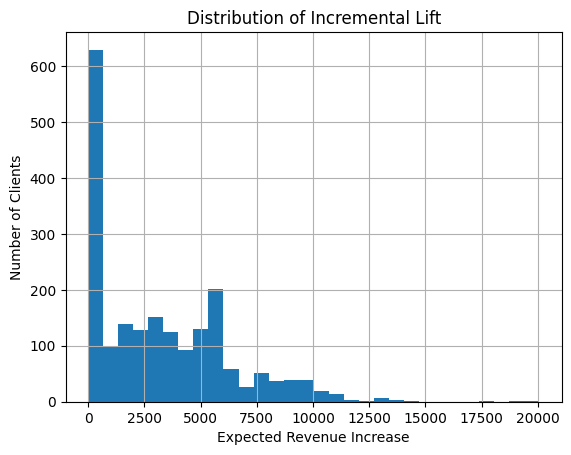

In [12]:
df['recommended_action'].value_counts().plot(kind='bar', title='Recommended Actions')
plt.show()

# Distribution of incremental lift
df['incremental_lift'].hist(bins=30)
plt.title('Distribution of Incremental Lift')
plt.xlabel('Expected Revenue Increase')
plt.ylabel('Number of Clients')
plt.show()

In [ ]:
# Next step - need to think about actual policy
# i.e add treatments only if increase > x
# remove treaments only if decrease > y (y much greater than x)